# In-situ Electrochemical SAXS analysis

In [38]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import glob
import os
import numpy as np
import pandas as pd
# import scienceplots
from galvani import BioLogic as BL
import eclabfiles as ecf
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display
from pybaselines import Baseline, utils
from scipy.signal import savgol_filter # Savitzky-Golay filter

# Define Functions

# Function for reading files 

In [2]:
import pandas as pd
import re

def read_data(file_name):
    legend_temp = None
    time_stamp_temp = None
    data_lines = []
    data_storing = False  # Flag to detect when to start reading data

    with open(file_name, 'r') as file:
        for line in file:
            line = line.strip()  # Remove leading/trailing spaces

            # Detect the last separator line and start storing data
            if line.startswith("################################################################################"):
                data_storing = True  # Start reading data after the last separator
                continue

            # Extract metadata
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2]
                
            # Store numerical data after the separator
            if data_storing and line and not line.startswith("#"):  # Ignore empty and comment lines
                data_lines.append(line)

    # Ensure we have data before processing
    if len(data_lines) < 2:  # Must have at least one data row + header
        print("No data found in the file!")
        return legend_temp, time_stamp_temp, None

    # Convert data into a DataFrame (handle variable spaces properly)
    df_temp = pd.DataFrame([re.split(r'\s+', line) for line in data_lines])

    # Assign correct column names from the first row
    df_temp.columns = df_temp.iloc[0]  # First row contains column names
    df_temp = df_temp[1:]  # Remove the header row from data

    # Convert numeric columns to float
    df_temp = df_temp.apply(pd.to_numeric, errors='coerce')

    return legend_temp, time_stamp_temp, df_temp



# Find files corresponding to Electrochemical events

In [3]:
def find_nearest_time(target_time, time_dict):
    new_time_dict = {}
    
    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
    
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    
    return nearest_key, new_time_dict


# Read the variables file

In [4]:
# Initialize variables
directory_path = None
mpr_file_path = None
saxs_min_limit = None
saxs_max_limit = None
waxs_min_limit = None
waxs_max_limit = None

with open(r'E:\SAXS_WAXS\variables.txt', 'r') as file:
    lines = file.readlines()

for line in lines:
    stripped_line = line.strip()  # Remove leading/trailing whitespace and newlines
    
    # Skip comments and empty lines
    if not stripped_line or stripped_line.startswith("#"):
        continue
    
    if directory_path is None:
        directory_path = stripped_line
    elif mpr_file_path is None:
        mpr_file_path = stripped_line
    elif saxs_min_limit is None:
        saxs_min_limit = float(stripped_line)
    elif saxs_max_limit is None:
        saxs_max_limit = float(stripped_line)
    elif waxs_min_limit is None:
        waxs_min_limit = float(stripped_line)
    elif waxs_max_limit is None:
        waxs_max_limit = float(stripped_line)


# Example: Use the min and max limits
print(f"Files Directory path: {directory_path}")
print(f"SAXS Contourplot Limits: Min = {saxs_min_limit}, Max = {saxs_max_limit}")
print(f"WAXS Contourplot Limits: Min = {waxs_min_limit}, Max = {waxs_max_limit}")


Files Directory path: C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240820_2503SKJB_satDME_200HFE_120uL_1G1PS\cycle
SAXS Contourplot Limits: Min = 0.13, Max = 3.0
WAXS Contourplot Limits: Min = 22.0, Max = 30.0


# Function for the contour plots

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
from scipy.ndimage import gaussian_filter
import tkinter as tk
from tkinter import filedialog

def contourplot(
    plot_type, data_normalization, data_dictionary, new_time_dict,
    min_limit, max_limit, cmap_min=None, cmap_max=None,
    Normalization_file=None, save_plot=False, filename="contour_plot.png",
    decimal_points=2, scientific=False, y_axis_mode='time',
    colorbar_position='bottom'  # 'bottom' or 'side'
):
    # Constants
    wavelength_nm = 0.154  # Cu K-alpha wavelength in nm
    fntsize = 16  # Font size for labels
    plt.style.use('default')

    # Extracting time keys
    keys = list(new_time_dict.keys())
    time_t1 = []
    Intensity_list = []

    # Convert x-axis from q to 2θ if WAXS
    X1_data_temp = 10 * data_dictionary[starting_file].iloc[:, 0]
    if plot_type == 'waxs':
        X1_data_temp = 2 * np.degrees(np.arcsin((wavelength_nm * X1_data_temp) / (4 * np.pi)))
        x_label = '2θ (°)'
    else:
        x_label = 'q (nm$^{-1}$)'

    # Filter by q or 2θ range
    indices_within_range = np.where((X1_data_temp >= min_limit) & (X1_data_temp <= max_limit))
    X1_data_filtered_positions = X1_data_temp.iloc[indices_within_range]
    start_row = np.min(indices_within_range)
    end_row = np.max(indices_within_range)

    # Data Processing
    for file_number in range(starting_file, last_file + 1):
        if data_normalization == 'relative':
            norm_intensity = data_dictionary[file_number].iloc[start_row:end_row + 1, 1] / data_dictionary[Normalization_file].iloc[start_row:end_row + 1, 1]
        else:
            norm_intensity = data_dictionary[file_number].iloc[start_row:end_row + 1, 1]

        Intensity_list.append(norm_intensity.to_numpy())
        time_elapsed = float(keys[file_number - 1] - keys[starting_file - 1])
        time_t1.append(time_elapsed)

    # Create time or capacity axis
    time_hours = np.array(time_t1) / 3600
    if y_axis_mode == 'capacity':
        y_data = (np.array(time_t1) * applied_current) / (active_material_mass * 3.6)
        y_label = 'Specific Capacity (mAh g$^{-1}$)'
    else:
        y_data = time_hours
        y_label = 'Time (h)'

    normIntensity_array = np.array(Intensity_list)
    normIntensity_array = gaussian_filter(normIntensity_array, sigma=1)

    X, Y = np.meshgrid(X1_data_filtered_positions, y_data)
    cmap1 = plt.colormaps.get_cmap('viridis')

    # Setup figure
    fig, axs = plt.subplots(1, 2, figsize=(6, 8), sharey=True, gridspec_kw={'width_ratios': [1, 4]})

    # Left subplot: Potential vs selected Y-axis
    if y_axis_mode == 'capacity':
        left_y = ((elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0]) * applied_current) / (active_material_mass * 3.6)
    else:
        left_y = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0]) / 3600

    axs[0].plot(elec_df_2['Ewe/V'], left_y, color='r')
    axs[0].invert_xaxis()
    axs[0].set_ylabel(y_label, fontsize=fntsize)
    axs[0].set_xlabel('Potential (V)', fontsize=fntsize)
    axs[0].set_ylim(left_y.min(), left_y.max())

    # Right subplot: Contour plot
    contour = axs[1].contourf(X, Y, normIntensity_array, cmap=cmap1, vmin=cmap_min, vmax=cmap_max)

    # Color bar placement
    if colorbar_position == 'side':
        cbar = fig.colorbar(contour, ax=axs[1])
    else:
        cbar_ax = fig.add_axes([0.3, 0.08, 0.55, 0.03])
        cbar = fig.colorbar(contour, cax=cbar_ax, orientation='horizontal')

    cbar.set_label('Relative Intensity' if data_normalization == 'relative' else 'Intensity (a.u.)', fontsize=fntsize)

    # Set color bar ticks
    cbar_min = cmap_min if cmap_min is not None else normIntensity_array.min()
    cbar_max = cmap_max if cmap_max is not None else normIntensity_array.max()
    cbar_mid = (cbar_min + cbar_max) / 2

    if scientific:
        factor = 1e4
        cbar.set_ticks([cbar_min, cbar_mid, cbar_max])
        cbar.set_ticklabels([f"{cbar_min*factor:.{decimal_points}f}", f"{cbar_mid*factor:.{decimal_points}f}", f"{cbar_max*factor:.{decimal_points}f}"], fontsize=fntsize)
        cbar.ax.text(0.9, -0.8, "×10⁻⁴", transform=cbar.ax.transAxes, fontsize=8, ha='left', va='bottom')
    else:
        cbar.set_ticks([cbar_min, cbar_mid, cbar_max])
        cbar.set_ticklabels([f"{cbar_min:.{decimal_points}f}", f"{cbar_mid:.{decimal_points}f}", f"{cbar_max:.{decimal_points}f}"], fontsize=fntsize)

    # Special log scale for SAXS
    if plot_type == 'saxs':
        axs[1].set_xscale('log')
        axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
        ticks = [min_limit] + list(range(int(np.ceil(min_limit)), int(max_limit) + 1, 2))
        axs[1].set_xticks(ticks)
        axs[1].set_xticklabels([f'{tick:.1f}' for tick in ticks], fontsize=fntsize)
        axs[1].xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1, numticks=10))

    axs[1].set_xlabel(x_label, fontsize=fntsize)
    axs[0].tick_params(axis='both', labelsize=fntsize)
    axs[1].tick_params(axis='both', labelsize=fntsize)
    fig.subplots_adjust(wspace=0.05, left=0.15, right=0.85, top=0.85, bottom=0.2)

    if save_plot:
        root = tk.Tk()
        root.withdraw()
        save_path = filedialog.asksaveasfilename(defaultextension=".png", initialfile=filename, filetypes=[("PNG files", "*.png")])
        if save_path:
            plt.savefig(save_path, dpi=600)
            print(f"Plot saved to {save_path}")

    plt.show()


# Smooth the data

In [16]:
def smooth_data(data, window_length, polyorder):
    return savgol_filter(data, window_length, polyorder)

# Upload/read data files for SAXS

In [7]:
directory_path = r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\Cell3\data_reduced_with_mask'
mpr_file_path = r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\Cell3\cell3_20250210_SKJB_0pt94_SatDME-HFE_100uL_1G1PS_diamond_window_with-tape_C02.mpr'
os.chdir(directory_path)
mpr = BL.MPRfile(mpr_file_path)

file_list = glob.glob('*_0_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)
    
print('Number of files:',key)

Number of files: 385


# Plot Data

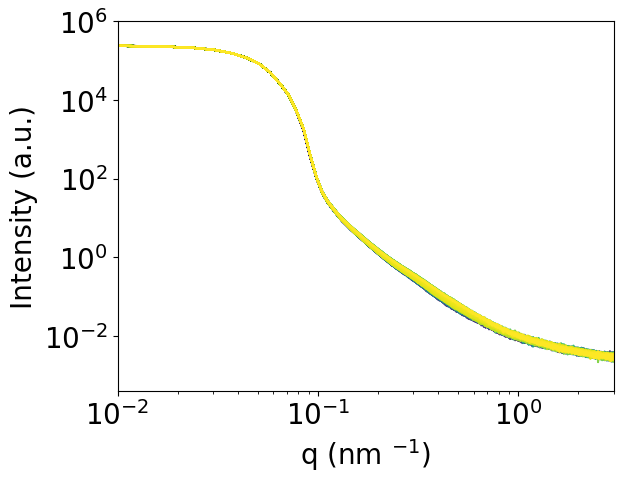

In [9]:

file_min = 5  # Start index of the files to plot
file_max = 350  # End index of the files to plot

plt.figure()
plt.style.use('default')

# Get 'viridis' colormap
cmap = plt.get_cmap('viridis')
files_to_plot = list(file_dictionary.keys())[file_min:file_max+1]  # Select keys in the specified range
num_files = len(files_to_plot)
colors = cmap(np.linspace(0, 1, num_files))  # Generate a range of colors for each selected file

# Plot each file in the specified range
for idx, (ikey, color) in enumerate(zip(files_to_plot, colors)):
    # print(f"Plotting file {ikey}...")
    X_data = 10 * file_dictionary[ikey].iloc[:, 0]  # Convert from inverse Å to inverse nm
    Y_data = file_dictionary[ikey].iloc[:, 1]
    plt.plot(X_data, Y_data, color=color, label=f"File {ikey}")

# Setting graph attributes
plt.xlim(0.01,3)
plt.ylim(0.0004,1000000)
plt.xlabel('q (nm $^{-1}$)', fontsize = 20)
plt.ylabel('Intensity (a.u.)', fontsize = 20)
plt.tick_params(labelsize = 20)

plt.xscale('log')
plt.yscale('log')

#plt.legend(title="Files", loc="best", fontsize="small", bbox_to_anchor=(1, 1))
#plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label='File Index', orientation='vertical')  # Optional: colorbar for reference
plt.show()


# Load electrochemical (EC Lab) file

Indices for cycle change [121, 4337, 8376, 12234, 15971, 19451, 22853, 26075, 29226, 30470]

Absolute times for change in electrochemical state: 
[120.00019696853997, 21187.679489594055, 41370.29756541207, 60648.49040132039, 79323.41294911958, 96713.25103571056, 113712.27301470487, 129807.33000758605, 145547.60677332478, 151763.1715458223]
Applied current 0.1573
Mass of active material 0.9391044502827659 mg


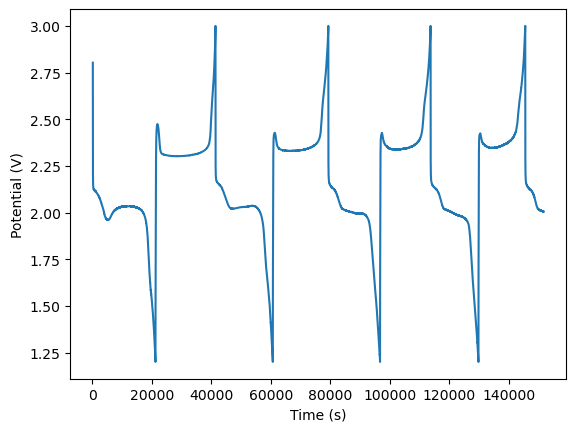

In [10]:
plt.figure()

elec_df_temp = pd.DataFrame(mpr.data)
rate = float(input("Enter discharge-charge rate, value of N in (C/N):"))

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
absolute_times_for_electrochemical_state_change = []

# Add the very first values of the index and time 
cycle_change_index.append(elec_df.index[0])
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[0], 'time/s'])

for line in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[line] != elec_df['Ns'].iloc[line+1]:
        cycle_change_index.append(elec_df.index[line+1])
        absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

cycle_change_index.append(elec_df.index[line+1]) #Takes the index for the last file also  
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

print("Indices for cycle change", cycle_change_index)
print("\nAbsolute times for change in electrochemical state: ")
print(absolute_times_for_electrochemical_state_change)

# Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')
applied_current = abs(elec_df['control/V/mA'].iloc[0])
print("Applied current",applied_current)
active_material_mass = (abs(elec_df['control/V/mA'].iloc[0])*1000*rate)/1675.0
print(f"Mass of active material {active_material_mass} mg")

# Data segregation 

In [11]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Define starting_cycle and end_cycle
starting_cycle = 1  # Set default starting cycle
end_cycle = 1  # Set default end cycle


def file_sorting(starting_cycle= starting_cycle, end_cycle= end_cycle, plot=False):

    change_cycle_line = []
    discharge_start_time = []
    saxs_file_numbers = []

    starting_index_for_EC_data = 2*starting_cycle-2
    ending_index_for_EC_data = 2*end_cycle

    print('\nBiologic data file line details:')
    print('Line numbers for each electrochemical change event :',
        [cycle_change_index[_] for _ in range(starting_index_for_EC_data, ending_index_for_EC_data+1)])
    print('Corresponding times for each electrochemical change event: ', 
        [f"{absolute_times_for_electrochemical_state_change[i]:.2f}" for i in range(2*starting_cycle-2, 2*end_cycle+1)])

    # creates a new data frame for the plot
    elec_df_2 = elec_df.iloc[cycle_change_index[starting_index_for_EC_data] - cycle_change_index[0] : 
                            cycle_change_index[ending_index_for_EC_data] - cycle_change_index[0]]
    elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')
    
    
      
    # find the corresponding starting abd ending SAXS file
    
    for entry in range(starting_index_for_EC_data, ending_index_for_EC_data+1):
        saxs_file_index, new_time_dict  = find_nearest_time(absolute_times_for_electrochemical_state_change[entry], time_stamp)
        saxs_file_numbers.append(saxs_file_index)
        X1_data = 10*file_dictionary[saxs_file_index].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y1_data = file_dictionary[saxs_file_index].iloc[:,1]
    print("Files numbers for SAXS data",saxs_file_numbers)
    starting_file = saxs_file_numbers[0]
    discharge_file = saxs_file_numbers[1]
    last_file = saxs_file_numbers[-1]
         
    return starting_file, discharge_file, last_file, new_time_dict, elec_df_2

Total number of cycles: 5


# assign capacity and potential to each saxs file 

In [12]:
def assign_capacity_and_potential_to_files(start_file, end_file, file_to_time_dict, elec_df, applied_current, active_material_mass):

    time_series = elec_df['time/s']
    voltage_series = elec_df['Ewe/V']
    
    capacity_dict = {}
    potential_dict = {}

    for file_index in range(start_file, end_file):
        time_in_s = file_to_time_dict.get(file_index, None)

        if time_in_s is not None:
            # Find the closest index in electrochemical time
            closest_idx = (time_series - time_in_s).abs().idxmin()
            matched_time = time_series.loc[closest_idx]
            matched_voltage = voltage_series.loc[closest_idx]

            # Compute capacity
            capacity = (matched_time * applied_current) / (active_material_mass * 3.6)

            # Save
            capacity_dict[file_index] = capacity
            potential_dict[file_index] = matched_voltage


    return capacity_dict, potential_dict


# Not required

In [ ]:
plt.figure()
print(f'profile for cycle number: {starting_cycle},{end_cycle}')
plt.style.use('default')
x_lim_min =0.15
x_lim_max = 3.15

plot1 = plt.subplot2grid((4, 4), (0, 0), colspan=4) 
plot2 = plt.subplot2grid((4, 4), (1, 0), rowspan=3, colspan=2) 
plot3 = plt.subplot2grid((4, 4), (1, 2), rowspan=3, colspan=2)

relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
plot1.plot(relative_time, elec_df_2['Ewe/V'], color = 'r')
# plot1.set_xlabel('Time(s)')
plot1.set_ylabel('Potential (V)')
plot1.set_xticks([])


norm = Normalize(vmin = starting_file, vmax = discharge_file+1)

for file_number in range(starting_file , discharge_file+1): 
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    mask = Y_data > 0
    X_data = X_data[mask]
    Y_data = Y_data[mask]
    
    color=cm.viridis(norm(file_number))
    plot2.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
# plot2.legend()
plot2.set_xlim(x_lim_min, x_lim_max)
plot2.set_ylim(0.002, 100)
plot2.set_xlabel('q (nm $^{-1}$)')
plot2.set_ylabel('Intensity (a.u.)')


"""plot2.set_xlim(1,30)
plot2.set_ylim(0.0004,0.01)"""
# plot2.set_title('charging')
plot2.set_yticks([])
plot2.set_yticklabels([])
plot2.set_xscale('log')
plot2.set_yscale('log')


norm = Normalize(vmin = discharge_file+1, vmax = last_file)

for file_number in range(discharge_file+1 , last_file+1):  
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    color=cm.viridis(norm(file_number))
    plot3.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
    
# plot3.legend()
plot3.set_xlim(x_lim_min, x_lim_max)
plot3.set_ylim(0.002, 100)
plot3.set_xlabel('q (nm $^{-1}$)')
"""plot3.set_xlim(1,30)
plot3.set_ylim(0.0004,0.01)"""
plot3.set_yticks([])
plot3.set_yticklabels([])
# plot3.set_title('discharge')
plot3.set_xscale('log')
plot3.set_yscale('log')
plt.tight_layout()

# SAXS Colourplot without background correction 


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]


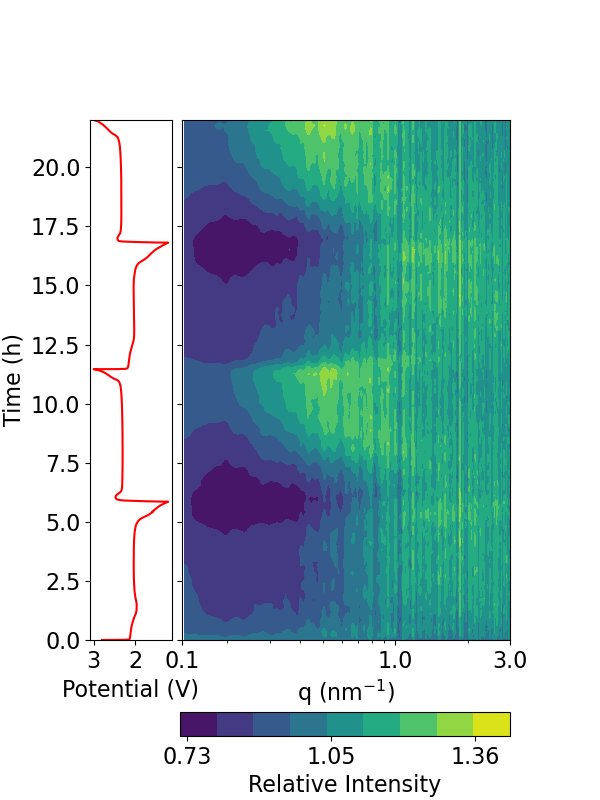

In [75]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 2, plot= False)
contourplot('saxs', 'relative', file_dictionary, new_time_dict, saxs_min_limit, 3, Normalization_file= starting_file, save_plot = False, 
            filename ="satDME.png",y_axis_mode= 'time', decimal_points=2, scientific=False)
#contourplot('saxs', 'absolute', file_dictionary, new_time_dict, saxs_min_limit, saxs_max_limit)

# Background correction with empty cell subtraction 

File used for background: EmptyCell_0_00000_2D_sum_azimAvg.dat


(0.01, 6)

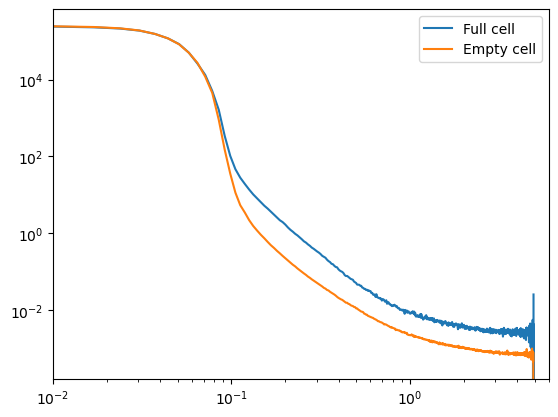

In [13]:
os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\EmptyCell\data_to_use')
saxs_background_file =  glob.glob('EmptyCell_0_00000_2D_sum_azimAvg.dat')#glob.glob('20240730_Empty_Cell_saxs.dat')
#print(file_list)
for file in saxs_background_file:
    a1,a2,SAXS_background = read_data(file)

plt.figure()  
print('File used for background:',file)

plt.plot(10*file_dictionary[1].iloc[:,0],file_dictionary[1].iloc[:,1], label = 'Full cell')
plt.plot(10*SAXS_background.iloc[:,0], SAXS_background.iloc[:,1], label = 'Empty cell')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(0.01,6)
#plt.ylim(0.001,40)
#print(SAXS_background)
# print(file_dictionary[1].head())
# print(file_dictionary[250].head())

# Create a new dictionary with corrected SAXS

(0.0001, 40)

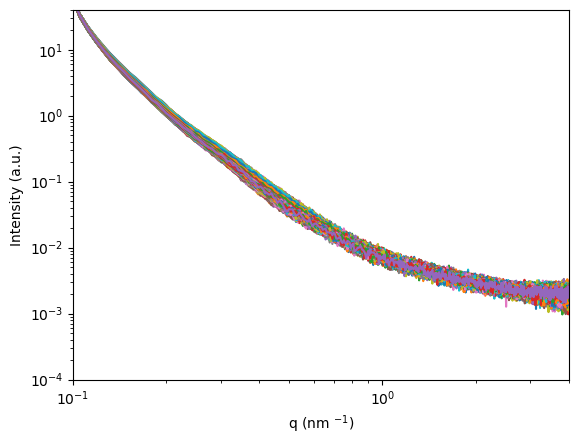

In [14]:
plt.figure()
emptyCell_corrected_saxs_files = {}
for ikey in file_dictionary:
    X_data = file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - SAXS_background.iloc[:len(Y_data),1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_saxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,4)
plt.ylim(0.0001,40)


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]
Normalized with - 55


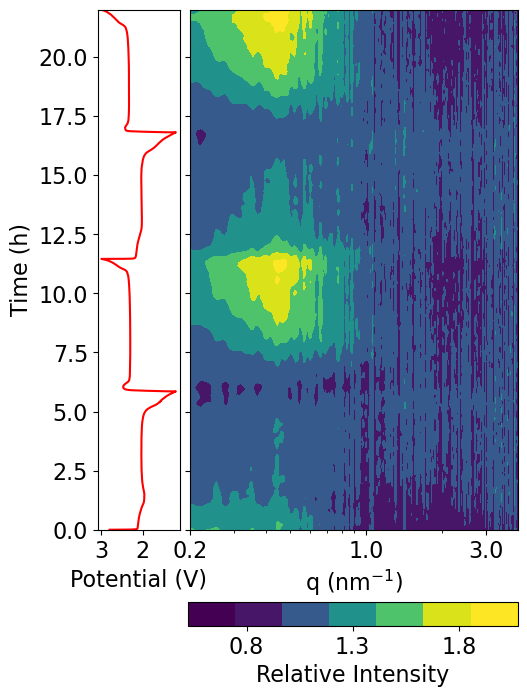

In [19]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 2, plot= False)
print(f'Normalized with - {discharge_file}')
#contourplot('saxs', 'relative', emptyCell_corrected_saxs_files, new_time_dict, 0.14, 4,  Normalization_file= discharge_file, save_plot= False)
contourplot('saxs', 'relative', emptyCell_corrected_saxs_files, new_time_dict, 0.2, 4, Normalization_file= discharge_file, 
            save_plot= True, cmap_min= 0.85, cmap_max=1.75, scientific= False, decimal_points= 1)

# Manual correction with perticular curve

# WAXS data polotting

In [23]:
directory_path = r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\cell3'
os.chdir(directory_path)
file_list_waxs = glob.glob('*_1_*.dat')
#print(file_list)


legend_waxs = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp_waxs = {} #Dictionary to store the time of file creation
key = 0
file_dictionary_waxs = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list_waxs:
    key += 1
    legend_waxs[key], time_stamp_waxs[key], file_dictionary_waxs[key] = read_data(data_file)
    
print('Number of files:',key)


Number of files: 385


# Plot the WAXS data

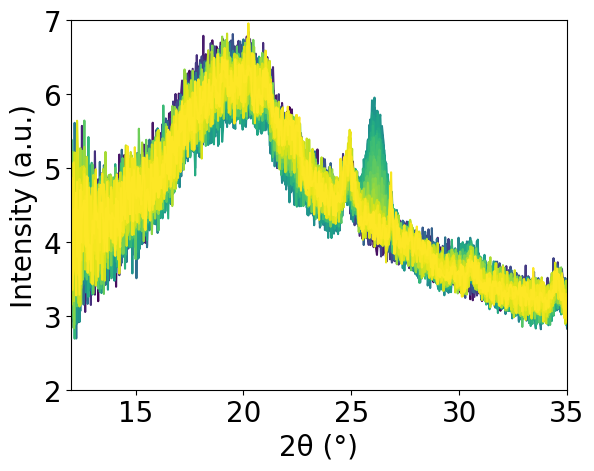

In [24]:
file_min = starting_file  # Start index of the files to plot
file_max = last_file  # End index of the files to plot

plt.figure()
plt.style.use('default')

# Get 'viridis' colormap
cmap = plt.get_cmap('viridis')
files_to_plot = list(file_dictionary_waxs.keys())[file_min:file_max+1]  # Select keys in the specified range
num_files = len(files_to_plot)
colors = cmap(np.linspace(0, 1, num_files))  # Generate a range of colors for each selected file

# Plot each file in the specified range
for idx, (ikey, color) in enumerate(zip(files_to_plot, colors)):
    X_data = 10 * file_dictionary_waxs[ikey].iloc[:, 0]  # Convert from inverse Å to inverse nm
    Y_data = file_dictionary_waxs[ikey].iloc[:, 1]
    plt.plot(2 * np.degrees(np.arcsin((0.154 * X_data) / (4 * np.pi))), 
             Y_data*1000, color=color, label=f"File {ikey}") # 0.154, wavelenght of Cu K alpha

# Setting graph attributes
plt.xlim(12,35)
plt.ylim(2,7)
plt.xlabel('2θ (°)', fontsize = 20)
plt.ylabel('Intensity (a.u.)', fontsize = 20)
#plt.yticks([])
plt.tick_params(labelsize = 20)



Biologic data file line details:
Line numbers for each electrochemical change event : [8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [106, 155, 202]


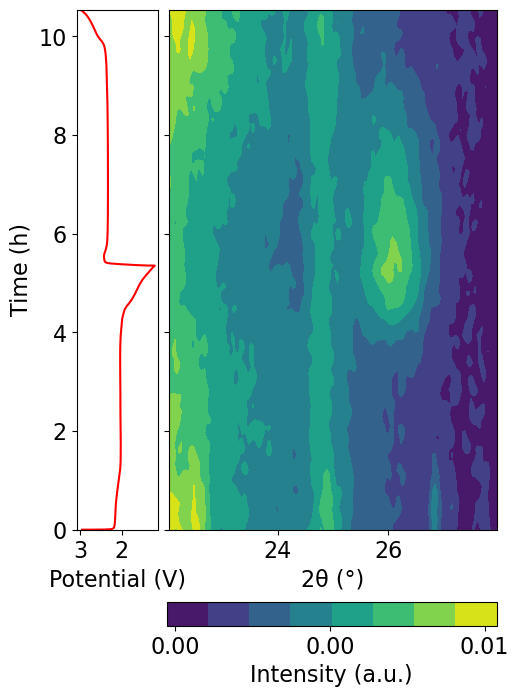

In [25]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 2, end_cycle = 2, plot= False)
contourplot('waxs', 'absolute', file_dictionary_waxs, new_time_dict, 22, 28, cmap_min= None, cmap_max= None)

# Background correction and plotting for the WAXS

# Background correction with empty cell subtraction 

File used for WAXS background: EmptyCell_1_00000_cumulated.dat


Text(0, 0.5, 'Intensity (a.u.)')

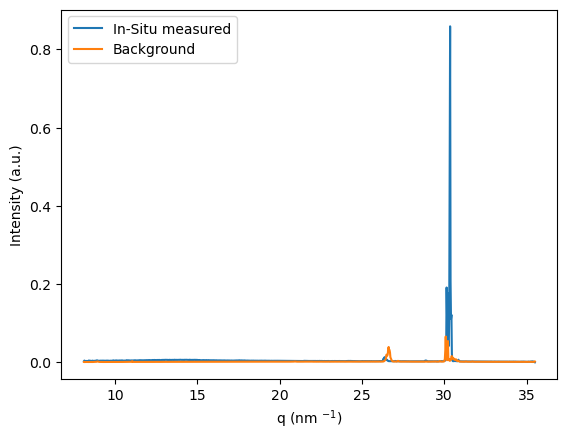

In [26]:
os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\EmptyCell')
#os.chdir(directory_path)
waxs_background_file =  glob.glob('EmptyCell_1_00000_cumulated.dat')
#glob.glob('20240730_Empty_Cell_waxs.dat')
WAXS_background = {} # Dictionary for storing all the pandas data file 

for file in waxs_background_file:
    a1,a2,WAXS_background = read_data(file)
    
print('File used for WAXS background:', file)
plt.figure()
plt.plot(10*file_dictionary_waxs[1].iloc[:,0], file_dictionary_waxs[1].iloc[:,1], label = "In-Situ measured")
plt.plot(10*WAXS_background.iloc[:,0], WAXS_background.iloc[:,1], label = 'Background')
plt.legend()
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

(-0.02, 0.05)

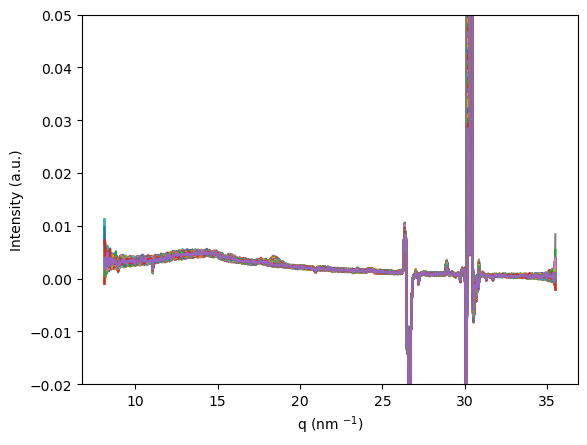

In [27]:
plt.figure()
emptyCell_corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - WAXS_background.iloc[:,1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02,0.05)
#print(corrected_waxs_files[1].head(30))

# Empty cell subtraction by matching peak at 9.68 

In [ ]:
plt.figure()
emptyCell_corrected_waxs_files2 = {}

for ikey in file_dictionary_waxs:
    # Extract X and Y data for the current file
    X_data = file_dictionary_waxs[ikey].iloc[:, 0]
    Y_data = file_dictionary_waxs[ikey].iloc[:, 1]
    
    # Interpolate Y values at X = 9.68 for both Y_data and WAXS_background
    target_X = 3.4
    if X_data.min() <= target_X <= X_data.max():
        Y_value_at_target = np.interp(target_X, X_data, Y_data)
        background_Y_value_at_target = np.interp(target_X, WAXS_background.iloc[:, 0], WAXS_background.iloc[:, 1])

        # Calculate the difference to align the background
        offset = Y_value_at_target - background_Y_value_at_target
        aligned_WAXS_background = WAXS_background.iloc[:, 1] + offset

        # Now subtract the aligned background from the raw Y_data
        modified_Y = Y_data - aligned_WAXS_background
#        plt.plot(10 * X_data, file_dictionary_waxs[ikey].iloc[:,1], label=f"raw {ikey}")
 #       plt.plot(10 * X_data, aligned_WAXS_background, label=f"background {ikey}")
        plt.plot(10 * X_data, modified_Y, label=f"Corrected {ikey}")

        # Store the results in the dictionary
        df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
        emptyCell_corrected_waxs_files2[ikey] = df
    else:
        print(f"Target X value {target_X} is out of range for file {ikey}")

# Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02, 0.05)
plt.show()

In [ ]:
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 1, plot= False)
contourplot('waxs', 'relative', emptyCell_corrected_waxs_files, new_time_dict, 24, 28, cmap_min= None , cmap_max= None, Normalization_file= discharge_file)
contourplot('waxs', 'absolute', emptyCell_corrected_waxs_files, new_time_dict, 24, 28, cmap_min= None , cmap_max= None, save_plot= True)
contourplot('waxs', 'absolute', emptyCell_corrected_waxs_files2, new_time_dict, 15, waxs_max_limit, cmap_min= None, cmap_max= None)

# Background correction with a polynomial (correction with only one background file)

In [ ]:
X_data = []
Y_data = []

for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary_waxs[files].iloc[:,1]
    else:
        x = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary_waxs[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 6)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

output_filename = "corrected_waxs.txt"
with open(output_filename, 'w') as f:
    for x,y in zip(X_data, modified_Y):
        f.write(f"{x}\t{y}\n")

print(f"first file printed as {output_filename}")

# Create background corrected WAXS dataframe

plt.figure("After polynomial background correction")

corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
#print(corrected_waxs_files[1].head(30))


# Correction with polynomial background on individual files 

filtered position: 220, 633, value: 1.3957449456344977, 2.496877061292659


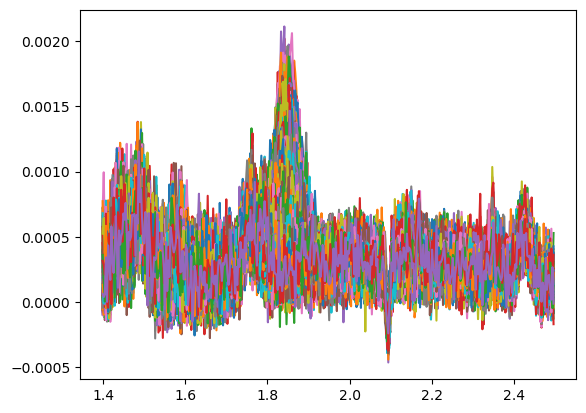

In [28]:
corrected_individual_waxs_files = {}
X_data = file_dictionary_waxs[1].iloc[:, 0]

# Ensure that the key `ikey` is properly iterated over the dictionary keys
data_to_plot = emptyCell_corrected_waxs_files
# filter the range for the WAXS
filtered_X_range_min = np.max(np.where(X_data <= 1.4))
filtered_X_range_max = np.max(np.where(X_data <= 2.5))
# print(empty_cell_corrected_waxs_files)
print(f"filtered position: {filtered_X_range_min}, {filtered_X_range_max}, value: {X_data[filtered_X_range_min]}, {X_data[filtered_X_range_max]}")

for ikey in data_to_plot.keys():  # Iterate over the keys of the dictionary
    min_val = 0
    max_val = 0
    modified_Y = 0
    X2_values = data_to_plot[ikey].iloc[filtered_X_range_min:filtered_X_range_max, 0] 
    Y1_values = data_to_plot[ikey].iloc[filtered_X_range_min:filtered_X_range_max, 1]
    
    baseline_filter = Baseline(x_data=X2_values)
    baseline = baseline_filter.modpoly(Y1_values, poly_order=3)[0]
    modified_Y = Y1_values - baseline
    plt.plot(X2_values, modified_Y)
    # Smooth the data
    # smoothed_Y = smooth_data(modified_Y, window_length=11, polyorder=2)

    # min_val = np.min(smoothed_Y)
    # max_val = np.max(smoothed_Y)
    # normalized_Y = smoothed_Y  # '(smoothed_Y - min_val)/(max_val - min_val)' # Normalized the data between [0,1]
    df = pd.DataFrame({'X_data': X2_values, 'Modified_Y': modified_Y})  # change the 'Modified_Y' as per the requirement, raw, smoothened or smoothened plus normalized 
    corrected_individual_waxs_files[ikey] = df

# Colour plot of Background corrected WAXS

profile for cycle number: 1 to 1

Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]


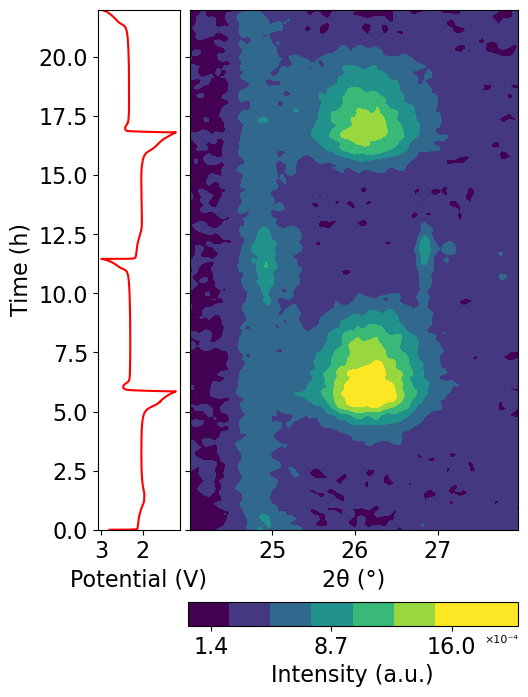

In [29]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 2, plot= False)
contourplot('waxs', 'absolute', corrected_individual_waxs_files, new_time_dict, 24, 28,  
            save_plot= True,  cmap_min= 1.4e-4, cmap_max= 16e-4, decimal_points=1,scientific=True)

# Waterfall plot for SAXS


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']
Files numbers for SAXS data [1, 55, 106]


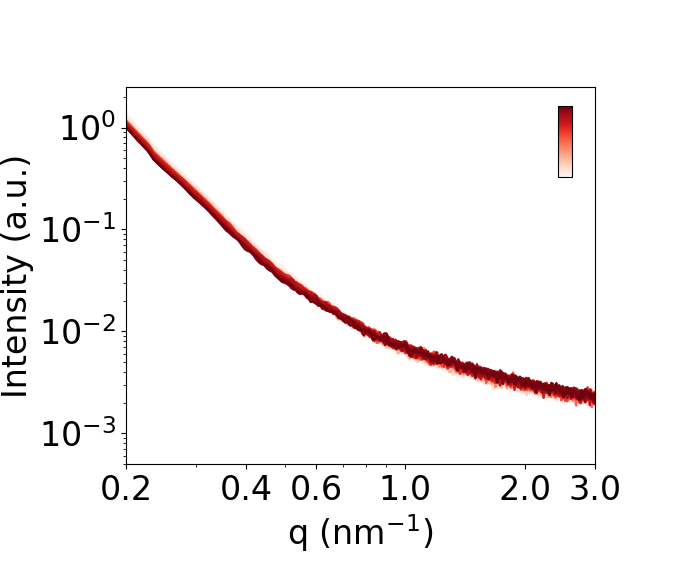

C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\EmptyCell
54


In [49]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import numpy as np

starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=1, plot=False)

file_list = emptyCell_corrected_saxs_files

starting_file_to_plot = starting_file+1
ending_file_to_plot = discharge_file

# starting_file_to_plot = discharge_file
# ending_file_to_plot = last_file-10

# Set up normalization for color mapping
norm_discharging = Normalize(vmin=starting_file_to_plot, vmax=ending_file_to_plot)

# Define axis limits and labels
x_lim_min, x_lim_max = 0.2, 3
y_lim_min, y_lim_max = 5e-4, 2.5
fntsize = 24

fig, ax = plt.subplots(figsize=(7,5.8))

# --- Plot: Discharging ---

for file_number in range(starting_file_to_plot, ending_file_to_plot):
    X_data = 10 * file_list[file_number].iloc[:, 0]  # Convert nm^-1
    Y_data = file_list[file_number].iloc[:, 1]  #/ file_list[starting_file].iloc[:, 1]

    # Filter the data to have better smoothing and plotting
    X_mask = X_data > x_lim_min
    X_data = X_data[X_mask]
    Y_data = Y_data[X_mask]

    # Mask all the sudden drops in the data to avoid sharp peaks
    mask = Y_data > 0.000
    X_data = X_data[mask]
    Y_data = Y_data[mask]

    # Apply Savitzky-Golay smoothing
    if len(Y_data) > 11:  # Ensure enough points for filtering
        Y_savgol = savgol_filter(Y_data, window_length=10, polyorder=4)
    else:
        Y_savgol = Y_data  # If too few points, use raw data

    # Apply multiplicative offset for better visualization in log scale
    offset = 1.02 ** (file_number - (starting_file_to_plot))  # Normalize offset
    Y_savgol = Y_savgol #* offset  

    # Ensure no zero values (important for log scale)
    Y_savgol[Y_savgol <= 0] = np.min(Y_savgol[Y_savgol > 0]) * 0.1

    # Define color
    color = cm.Reds(norm_discharging(file_number))
    
    # Plot the curve
    ax.plot(X_data, Y_savgol, label=str(time_stamp[file_number]), color=color)

ax.set_xlim(x_lim_min, x_lim_max)
ax.set_ylim(y_lim_min, y_lim_max)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(labelsize=fntsize)
ax.set_xlabel('q (nm$^{-1}$)', fontsize=fntsize)
ax.set_ylabel('Intensity (a.u.)', fontsize=fntsize)

ax.set_xticks([0.2, 0.4, 0.6, 1.0, 2.0, 3.0])
ax.set_xticklabels(['0.2', '0.4', '0.6', '1.0', '2.0', '3.0'], fontsize=fntsize)

# --- Colorbar ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm_discharging)
sm.set_array([])
axins = inset_axes(ax, width="3%", height="20%", loc='upper right',
                   bbox_to_anchor=(0, 0, 0.95, 0.95),
                   bbox_transform=ax.transAxes, borderpad=0)
cbar = plt.colorbar(sm, cax=axins)
cbar.set_ticks([])

# Adjust layout
fig.subplots_adjust(left=0.18, right=0.85, top=0.85, bottom=0.2)

# Save and Show
plt.savefig("discharging1.png", dpi=600, format='png')
plt.show()

print(os.getcwd())
print(file_number)



Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']
Files numbers for SAXS data [1, 55, 106]


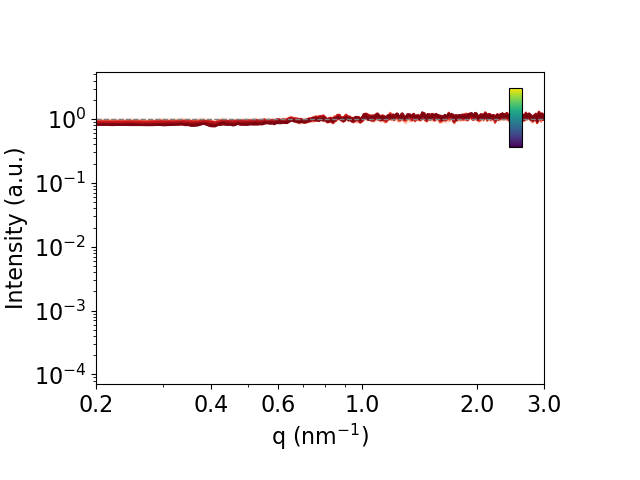

C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\EmptyCell
53


In [24]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Get data
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=1, plot=False)
file_list = file_dictionary

# Color normalization
norm_discharging = Normalize(vmin=starting_file + 4, vmax=discharge_file)

# Plot setup
x_lim_min, x_lim_max = 0.2, 3
fntsize = 16
fig, ax = plt.subplots()

# === Get and smooth the reference curve ===
ref_Y = file_list[starting_file + 4].iloc[:, 1].values
ref_Y = savgol_filter(ref_Y, window_length=11, polyorder=4)
ref_Y[ref_Y <= 0] = np.min(ref_Y[ref_Y > 0]) * 0.1

# === Plotting loop ===
for file_number in range(starting_file + 4, discharge_file - 1):
    X_data = 10 * file_list[file_number].iloc[:, 0].values  # Convert q to nm^-1
    Y_data = file_list[file_number].iloc[:, 1].values

    # Smooth Y_data
    if len(Y_data) > 11:
        Y_data = savgol_filter(Y_data, window_length=11, polyorder=4)

    # Avoid zero values
    Y_data[Y_data <= 0] = np.min(Y_data[Y_data > 0]) * 0.1

    # Normalize against reference
    Y_norm = Y_data / ref_Y
    Y_norm[Y_norm <= 0] = np.min(Y_norm[Y_norm > 0]) * 0.1

    # Mask q-range and valid intensity
    mask = (X_data > x_lim_min) & (Y_norm > 0)
    X_data = X_data[mask]
    Y_norm = Y_norm[mask]

    # Offset to visually separate curves
    offset = 1.03 ** (file_number - (starting_file + 4))
   # Y_norm *= offset

    # Colormap and plot
    color = cm.Reds(norm_discharging(file_number))
    ax.plot(X_data, Y_norm, color=color)

# === Axes settings ===
ax.set_xlim(x_lim_min, x_lim_max)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(labelsize=fntsize)
ax.set_xlabel('q (nm$^{-1}$)', fontsize=fntsize)
ax.set_ylabel('Intensity (a.u.)', fontsize=fntsize)

ax.set_xticks([0.2, 0.4, 0.6, 1.0, 2.0, 3.0])
ax.set_xticklabels(['0.2', '0.4', '0.6', '1.0', '2.0', '3.0'], fontsize=fntsize)

# === Optional horizontal reference line at y=1 ===
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)

# === Colorbar ===
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_discharging)
sm.set_array([])
axins = inset_axes(ax, width="3%", height="20%", loc='upper right',
                   bbox_to_anchor=(0, 0, 0.95, 0.95),
                   bbox_transform=ax.transAxes, borderpad=0)
cbar = plt.colorbar(sm, cax=axins)
cbar.set_ticks([])

# Layout
fig.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.2)

# Save + show
plt.savefig("discharging1_enhanced.png", dpi=600, format='png')
plt.show()

print(os.getcwd())
print(file_number)


# Manually plot certain saxs and waxs file

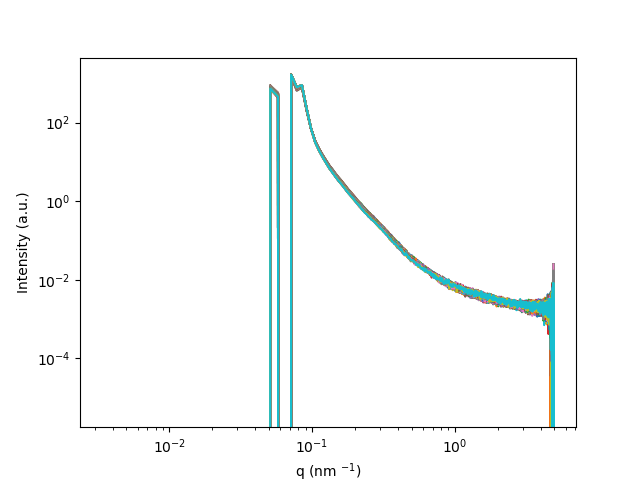

In [117]:
# Manual data plotting SAXS
plt.figure()

for ikey in range(5,55):
    X_data = 10*emptyCell_corrected_saxs_files[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = emptyCell_corrected_saxs_files[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

plt.xscale('log')
plt.yscale('log')

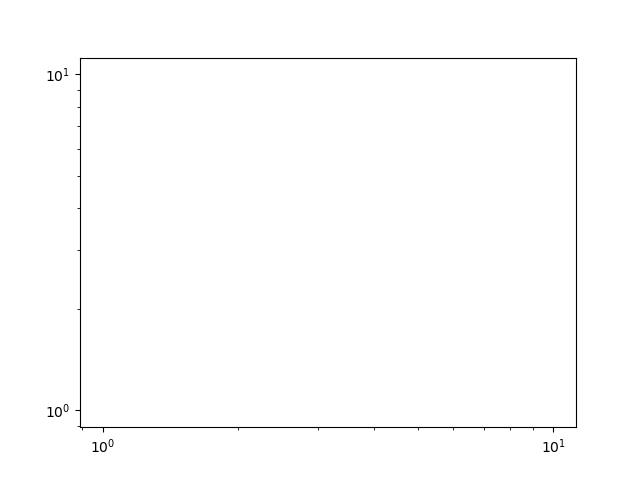

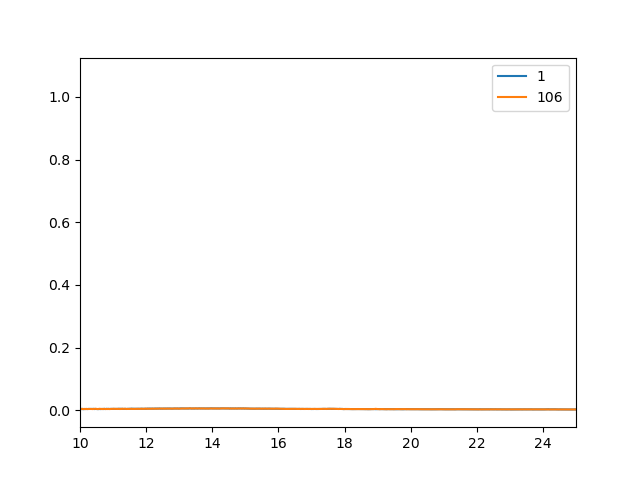

In [141]:
# Manual data plotting WAXS
plt.figure()
for ikey in range(106,106):
    X_data = 10*emptyCell_corrected_saxs_files[169].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = emptyCell_corrected_saxs_files[169].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xscale('log')
plt.yscale('log')
plt.figure()
for ikey in [1,106]:
    X_data = 10*file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    plt.plot(X_data, Y_data, label= ikey)
    plt.xlim(10,25)
plt.legend()

# Find average intensity, mean q and invariance within a certain q range


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]
File to time dictionary: {1: 0.0, 2: 394.0, 3: 788.0, 4: 1181.0, 5: 1575.0, 6: 1969.0, 7: 2364.0, 8: 2758.0, 9: 3152.0, 10: 3546.0, 11: 3940.0, 12: 4333.0, 13: 4728.0, 14: 5121.0, 15: 5516.0, 16: 5909.0, 17: 6303.0, 18: 6697.0, 19: 7091.0, 20: 7485.0, 21: 7879.0, 22: 8273.0, 23: 8667.0, 24: 9060.0, 25: 9454.0, 26: 9848.0, 27: 10241.0, 28: 10636.0, 29: 11030.0, 30: 11423.0, 31: 11818.0, 32: 12211.0, 33: 12605.0, 34: 13000.0, 35: 13393.0, 36: 13787.0, 37: 14181.0, 38: 14575.0, 39: 14968.0, 40: 15362.0, 41: 15756.0, 42: 16149.0, 43: 16543.0, 44: 16937.0, 45: 17332.0, 46: 17726.0, 47: 18120.0, 48: 18514.0, 49: 18908.0, 50: 19302.0, 51: 19695.0, 52: 20090.0, 53: 20483.0, 54: 20878.0, 55: 21272.0, 56: 21665.

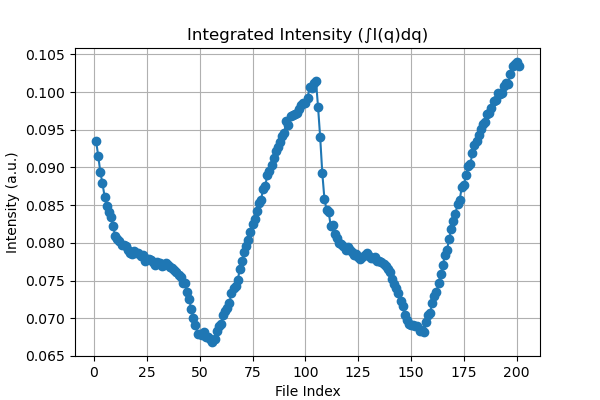

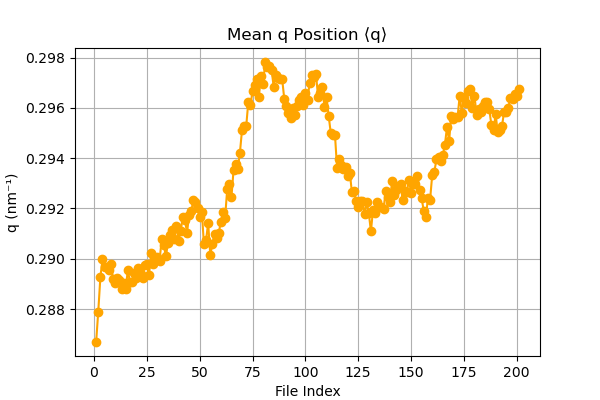

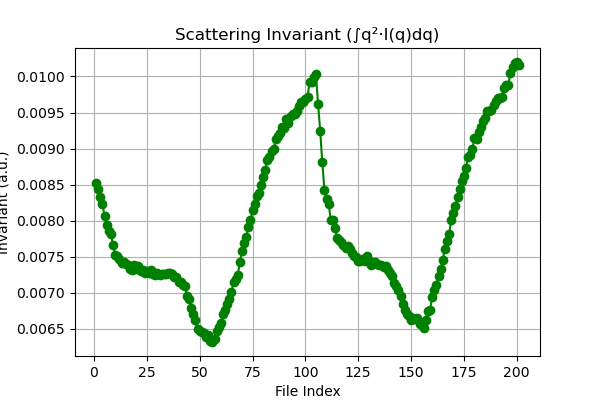

Saved SAXS summary to :C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\EmptyCell\data_to_use/saxs_summary_output_standard_cell_christian_cell.txt


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import os

# Load sorted files (your function)
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=2, plot=False)

file_to_time_dict = {v: k for k, v in new_time_dict.items()}
print (f"File to time dictionary: {file_to_time_dict}")
capacity_dict, potential_dict = assign_capacity_and_potential_to_files(
    starting_file, last_file,
    file_to_time_dict,
    elec_df_2,
    applied_current,
    active_material_mass
)

# SAXS file dictionary
fileset_dictionary = emptyCell_corrected_saxs_files  # <-- Make sure this is loaded


# q-range in nm⁻¹
q_min_nm = 0.2
q_max_nm = 0.7
# q_min_nm = 0.8
# q_max_nm = 3



# Storage
intensity_dictionary = {}
mean_q_dictionary = {}
invariant_dictionary = {}

for file in range(starting_file, last_file):
    if file not in fileset_dictionary:
        continue

    q_nm = 10 * fileset_dictionary[file].iloc[:, 0]  # Convert Å⁻¹ to nm⁻¹
    I_q = fileset_dictionary[file].iloc[:, 1]

    mask = (q_nm >= q_min_nm) & (q_nm <= q_max_nm)
    #mask = (q_nm >= 0.2) & (q_nm <= 4)
    q_vals = q_nm[mask].values
    I_vals = I_q[mask].values

    if len(q_vals) < 2:
        continue

    # Intensity: ∫ I(q) dq
    total_I = simpson(I_vals, x=q_vals)

    # Mean q: ∫ q·I(q)dq / ∫ I(q)dq
    q_mean = simpson(q_vals * I_vals, x=q_vals) / total_I if total_I != 0 else np.nan

    # Invariant: ∫ q²·I(q) dq
    invariant = simpson(q_vals**2 * I_vals, x=q_vals)

    intensity_dictionary[file] = total_I
    mean_q_dictionary[file] = q_mean
    invariant_dictionary[file] = invariant

# ------------- Plotting ----------------

# 1. Total Intensity
plt.figure(figsize=(6, 4))
plt.plot(list(intensity_dictionary.keys()), list(intensity_dictionary.values()), marker='o')
plt.title('Integrated Intensity (∫I(q)dq)')
plt.xlabel('File Index')
plt.ylabel('Intensity (a.u.)')
plt.grid(True)
plt.show()

# 2. Mean q (⟨q⟩)
plt.figure(figsize=(6, 4))
plt.plot(list(mean_q_dictionary.keys()), list(mean_q_dictionary.values()), marker='o', color='orange')
plt.title('Mean q Position ⟨q⟩')
plt.xlabel('File Index')
plt.ylabel('q (nm⁻¹)')
plt.grid(True)
plt.show()

# 3. Scattering Invariant
plt.figure(figsize=(6, 4))
plt.plot(list(invariant_dictionary.keys()), list(invariant_dictionary.values()), marker='o', color='green')
plt.title('Scattering Invariant (∫q²·I(q)dq)')
plt.xlabel('File Index')
plt.ylabel('Invariant (a.u.)')
plt.grid(True)
plt.show()

# Save the results in a txt file 
save_files = True  # Set to False to skip saving

if save_files:
    output_file = "saxs_summary_output_standard_cell_christian_cell.txt"
    with open(output_file, "w") as f:
        # Write header
        f.write("File\tIntegrated_Intensity\tMean_q(nm^-1)\tInvariant\tCapacity(mAh/g)\tPotential(V)\n")

        # Write each row
        for key in intensity_dictionary:
            total_I = intensity_dictionary.get(key, np.nan)
            q_mean = mean_q_dictionary.get(key, np.nan)
            invariant = invariant_dictionary.get(key, np.nan)
            cap = capacity_dict.get(key, np.nan)
            pot = potential_dict.get(key, np.nan)
            f.write(f"{key}\t{total_I:.4e}\t{q_mean:.4f}\t{invariant:.4e}\t{cap:.4f}\t{pot:.4f}\n")

    print(f"Saved SAXS summary to :{os.getcwd()}/{output_file}")


# 3D waterfall plot for WAXS 


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']
Files numbers for SAXS data [1, 55, 106]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


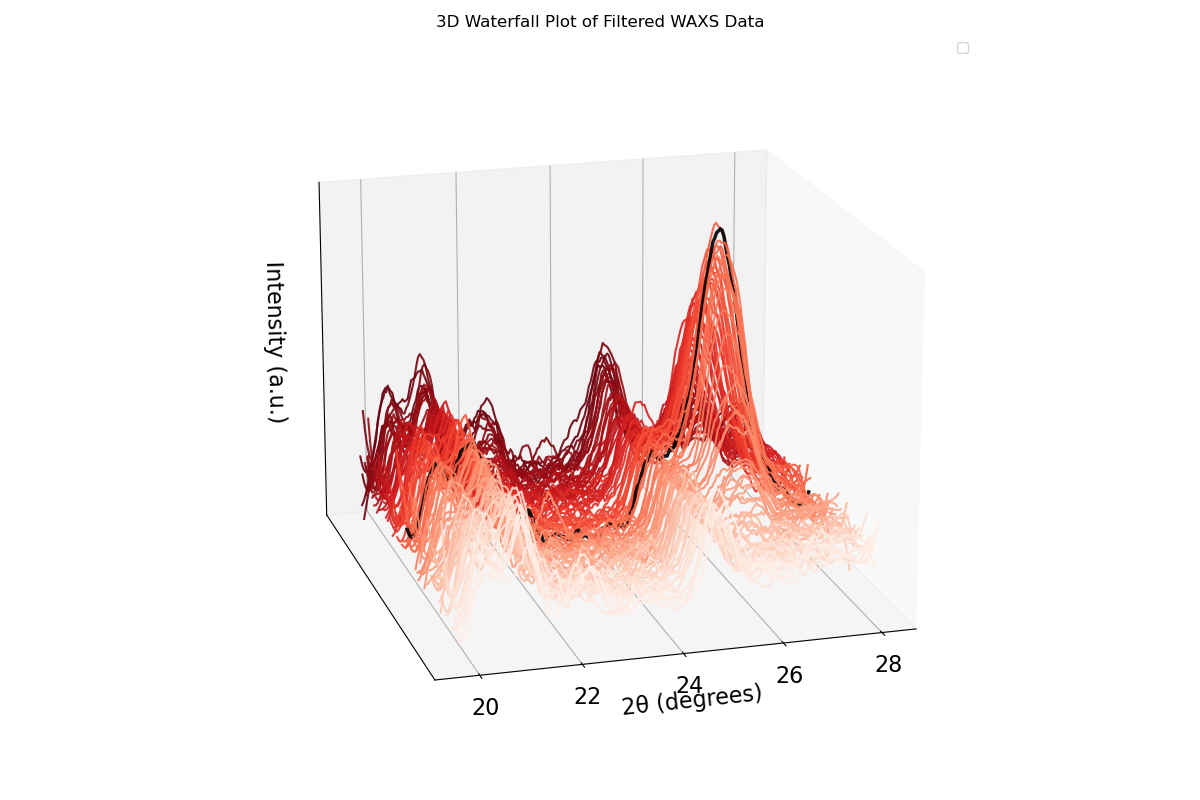

In [119]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 1, plot= False)

# Assuming data_to_plot, starting_file, last_file, saxs_file_numbers, and discharge_file are defined
data_to_plot = corrected_individual_waxs_files

# Wavelength for Cu Kα in nm
wavelength = 0.15406  # nm

# Function to convert q (nm^-1) to 2theta (degrees)
def q_to_two_theta(q_values, wavelength):
    return 2 * np.degrees(np.arcsin((q_values * wavelength) / (4 * np.pi)))

# Initialize the figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
plt.title("3D Waterfall Plot of Filtered WAXS Data")

# Define filtering limits
q_min, q_max = 12, 19.8 #16.9
intensity_min, intensity_max = 0, 0.02  # Adjust as necessary

# Base offset for the waterfall plot
base_offset = 0.0
offset_increment = 0.000002  # Smaller value to improve spacing

# Set transparency
transparency = 0.9

# List of keys and reverse it
keys = list(range(starting_file+4, last_file + 1, 1))
keys.reverse()

# Ensure discharge_file is included in keys
if discharge_file not in keys:
    keys.append(discharge_file)
    keys = sorted(keys, reverse=True)  # Keep keys in reverse order for consistency

# Adjust the saxs_file_numbers list to exclude the first and last entries
#adjusted_saxs_file_numbers = saxs_file_numbers[1:-1]

for ikey in keys:
    # Extract X and Y values
    original_q = 10 * data_to_plot[ikey].iloc[:, 0]  # q values in nm^-1
    original_Y = data_to_plot[ikey].iloc[:, 1]  # Intensity values
    
    # Convert q to 2theta
    converted_two_theta = q_to_two_theta(original_q, wavelength)
    
    # Filter data based on limits
    filtered_indices = (original_q >= q_min) & (original_q <= q_max) #& (original_Y >= intensity_min) & (original_Y <= intensity_max)
    filtered_two_theta = converted_two_theta[filtered_indices]
    filtered_Y = original_Y[filtered_indices]
    
    # Apply vertical offset for Z-axis
    offset = base_offset + (ikey - starting_file) * offset_increment
    Z = np.full_like(filtered_two_theta, offset)
    
    # Check if the current file is the discharge file
    if ikey == discharge_file:
        # Plot the discharge file in black and bold
        ax.plot(filtered_two_theta, Z, savgol_filter(filtered_Y, window_length=20, polyorder=3)*1000, 
                color='black', linewidth=2.5, alpha=transparency)
    else:
        # Plot other files with default style
        ax.plot(filtered_two_theta, Z, savgol_filter(filtered_Y, window_length=20, polyorder=3)*1000, 
                color=cm.Reds((ikey - starting_file) / (last_file - starting_file)), 
                alpha=transparency)

# Set axis labels
ax.set_xlabel('2θ (degrees)',fontsize=16)  # Update x-axis label to 2theta
ax.tick_params(axis='x', labelsize=16)
ax.set_yticks([])  # Hide y-ticks for offset
ax.set_zticks([])  # Hide z-ticks for intensity
ax.set_zlabel('Intensity (a.u.)', fontsize=16)  # Update z-axis label to intensity


# Add legend for discharge file
ax.legend(loc="upper right")

# Adjust view angle
ax.view_init(elev=18, azim=-106)

# Show plot
plt.tight_layout()
plt.show()


# 2D WAXS waterfall plot 


Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30']
Files numbers for SAXS data [1, 55, 106]


C:\Users\b1104371\AppData\Local\Temp\ipykernel_55000\3912582035.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues', num_curves)
C:\Users\b1104371\AppData\Local\Temp\ipykernel_55000\3912582035.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


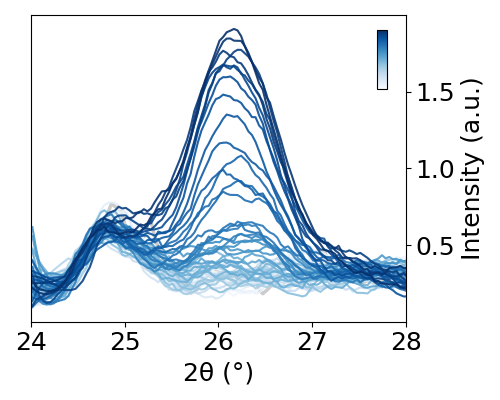

the plot is saved in the directory C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\Christian_cells\EmptyCell


In [52]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import os 

starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle = 1, end_cycle = 1, plot= False)

# Assuming data_to_plot, starting_file, last_file, saxs_file_numbers, and discharge_file are defined
data_to_plot = corrected_individual_waxs_files
# Color normalization


# Function to convert q (nm^-1) to 2theta (degrees)
def q_to_two_theta(q_values, wavelength):
    return 2 * np.degrees(np.arcsin((q_values * wavelength) / (4 * np.pi)))

# Wavelength for Cu Kα in nm
wavelength = 0.15406  # nm

# Define filtering limits
q_min, q_max = 16.96, 21.12
intensity_min, intensity_max = 0, 0.02  # Adjust as necessary

# Create figure for 2D waterfall plot
fig, ax = plt.subplots(figsize=(5,4))
#ax.set_title("2D Waterfall Plot of WAXS Data (Smoothed)", fontsize=16)

# Base offset for the 2D stacked plot
offset_increment = 0.00001  # Adjust to control spacing

# List of keys and reverse them for waterfall effect
keys = list(range(starting_file+0, discharge_file + 1))
#keys.reverse()
norm_discharging = Normalize(vmin=starting_file + 0, vmax=discharge_file+1)

# Ensure discharge_file is included in keys
if discharge_file not in keys:
    keys.append(discharge_file)
    keys = sorted(keys, reverse=False)  # Keep keys in reverse order for consistency

# Define color gradient for normal curves (Greyscale)
num_curves = len(keys)
cmap = cm.get_cmap('Blues', num_curves)

for idx, ikey in enumerate(keys):
    # Extract X and Y values from actual data
    original_q = 10 * data_to_plot[ikey].iloc[:, 0]  # q values in nm^-1
    original_Y = data_to_plot[ikey].iloc[:, 1]  # Intensity values

    # Convert q to 2theta
    converted_two_theta = q_to_two_theta(original_q, wavelength)

    # Filter data based on limits
    valid_indices = (original_q >= q_min) & (original_q <= q_max) & (original_Y >= intensity_min) & (original_Y <= intensity_max)
    filtered_two_theta = converted_two_theta[valid_indices]
    filtered_Y = original_Y[valid_indices]

    # Apply Savitzky-Golay filtering for smoothing (window=7, polynomial order=3)
    if len(filtered_Y) > 7:  # Ensure enough points for filtering
        smoothed_Y = savgol_filter(filtered_Y, window_length=20, polyorder=3)*1000
    else:
        smoothed_Y = filtered_Y *1000 # If too few points, use raw data

    # Apply vertical offset for stacked appearance
    offset = idx * offset_increment

    # Check if the current file is the discharge file
    if ikey == starting_file+0:
        # **Discharge file in bold black**
        ax.plot(filtered_two_theta, savgol_filter(filtered_Y, window_length=10, polyorder=2)*1000 + offset, color='black', linewidth=2.5, alpha=0.2)
    else:
        # **Other curves in fading grayscale**
        ax.plot(filtered_two_theta, smoothed_Y + offset, color=cmap(idx / num_curves), alpha=0.9)


# Colorbar inside top-right corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create ScalarMappable for colorbar
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm_discharging)
sm.set_array([])

# Positioning colorbar inside plot (top right corner)
axins = inset_axes(ax, width="3%", height="20%", loc='upper right',
                   bbox_to_anchor=(0, 0, 0.95, 0.95),
                   bbox_transform=ax.transAxes, borderpad=0)

cbar = plt.colorbar(sm, cax=axins)
cbar.set_ticks([])

# Set axis labels
ax.set_xlim(24, 28)
ax.set_xlabel('2θ (°)', fontsize=18)
ax.set_ylabel('Intensity (a.u.)', fontsize=18)

# Remove y-ticks for a cleaner waterfall effect
#ax.set_yticks([])
# Move y-axis ticks and ticklabels to the right side
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.tick_params(axis='both', labelsize=18) 
# Add legend for discharge curve
#ax.legend(loc="upper right", fontsize=12)

# Adjust layout and show plot
plt.tight_layout()
plt.show()
plt.savefig("2D_Waterfall_Plot_WAXS.png", dpi=600, format='png')
print(f'the plot is saved in the directory {os.getcwd()}')

# Find the peak positions and determine the FWHM maually without lorenzian fitting 

In [108]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from IPython.display import display


data_to_plot = corrected_individual_waxs_files # mentions the dictionary to be used for plotting
print(f"Number of keys in data_to_plot: {len(data_to_plot)}")
# Constants
wavelength = 0.154  # in nm
K = 0.9  # Scherrer shape factor
q_min, q_max = 12, 21.12  # q-range limits 16.96

# Get data
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=2, plot=False)

print(f"Starting file: {starting_file}, Last file: {last_file}")

keys = list(range(starting_file, last_file+1))


# Peak(s) to track (in 2θ)
peak_guesses = [26]

# Storage
results = []

# Conversion function
def q_to_two_theta(q_values, wavelength):
    return 2 * np.degrees(np.arcsin((q_values * wavelength) / (4 * np.pi)))

# Main loop
for idx, ikey in enumerate(keys):
    if ikey not in data_to_plot:
        print(f"Key {ikey} not found. Skipping...")
        continue

    # Extract q and intensity
    original_q = 10 * data_to_plot[ikey].iloc[:, 0]  # q (nm⁻¹)
    original_Y = data_to_plot[ikey].iloc[:, 1]       # intensity

    # Convert to 2θ
    two_theta = q_to_two_theta(original_q, wavelength)

    # Filter q-range
    valid = (original_q >= q_min) & (original_q <= q_max)
    x = two_theta[valid]
    y = original_Y[valid]

    # Smooth data
    y_smoothed = savgol_filter(y, 21, 3)*1000 if len(y) > 21 else y*1000

    for peak_guess in peak_guesses:
        # Get window around guess ±0.5°
        window = (x >= peak_guess - 2) & (x <= peak_guess + 2)
        x_win = np.array(x[window])
        y_win = np.array(y_smoothed[window])

        if len(x_win) < 3:
            continue

        # Find peak
        max_idx = np.argmax(y_win)

        peak_pos = x_win[max_idx]
        peak_height = y_win[max_idx]
        half_max = peak_height / 2

        # Find left crossing
        left = np.where(y_win[:max_idx] <= half_max)[0]
        right = np.where(y_win[max_idx:] <= half_max)[0]

        if len(left) == 0 or len(right) == 0:
            continue

        # Interpolate left
        l = left[-1]
        x1, x2 = x_win[l], x_win[l+1]
        y1, y2 = y_win[l], y_win[l+1]
        left_cross = x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

        # Interpolate right
        r = right[0] + max_idx
        x1, x2 = x_win[r-1], x_win[r]
        y1, y2 = y_win[r-1], y_win[r]
        right_cross = x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

        # Calculate FWHM
        fwhm = right_cross - left_cross

        # Scherrer Equation
        #beta_deg = fwhm / 2
        beta_rad = np.radians(fwhm)
        theta_rad = np.radians(peak_pos / 2)

        crystallite_size = (K * wavelength) / (beta_rad * np.cos(theta_rad))

        # Store
        results.append({
            "File Key": ikey,
            "Peak Guess (2θ)": peak_guess,
            "Peak Position (2θ)": round(peak_pos, 2),
            "FWHM (2θ)": round(fwhm, 3),
            "Crystallite Size (nm)": round(crystallite_size, 2)
        })

# Create DataFrame
df_results = pd.DataFrame(results)

# Optionally merge with capacity if available
if "Discharge_Capacity" in elec_df_2.columns:
    df_results["Capacity"] = df_results["File Key"].map(elec_df_2["Discharge_Capacity"])

# Display
print("Scherrer Peak Analysis:")
display(df_results)


Number of keys in data_to_plot: 385

Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]
Starting file: 1, Last file: 202
Scherrer Peak Analysis:


,File Key,Peak Guess (2θ),Peak Position (2θ),FWHM (2θ),Crystallite Size (nm)
0,1,26,25.08,1.039,7.83
1,2,26,24.96,1.130,7.20
2,3,26,24.89,0.805,10.10
3,4,26,24.96,0.746,10.90
4,5,26,25.00,0.938,8.67
...,...,...,...,...,...
194,198,26,24.77,1.465,5.55
195,199,26,24.77,1.509,5.39
196,200,26,24.73,0.891,9.12
197,201,26,24.77,0.880,9.24


C:\Users\b1104371\AppData\Local\Temp\ipykernel_19236\3079336912.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(keys))


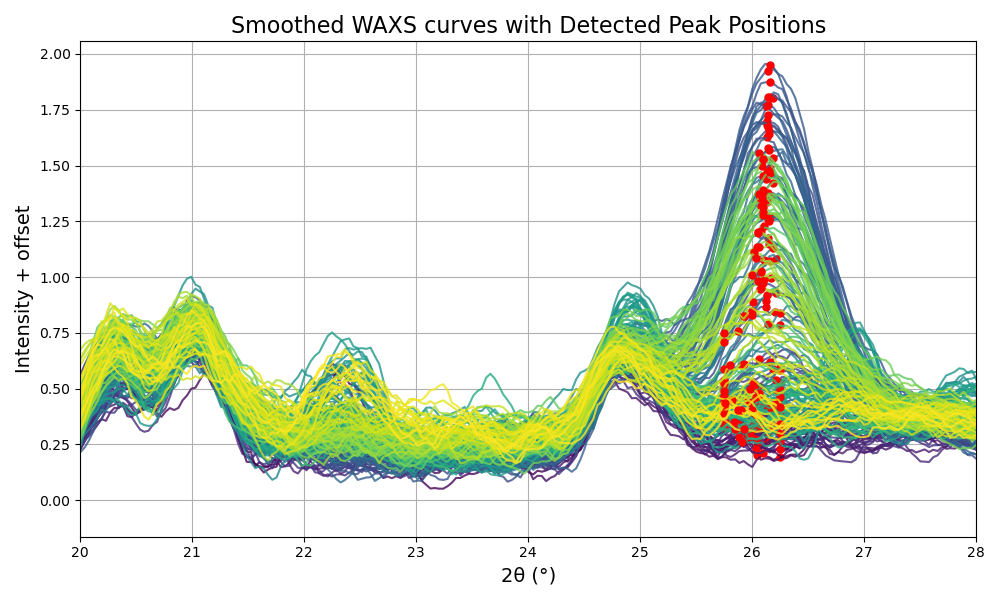

In [212]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Create a plot
fig, ax = plt.subplots(figsize=(10, 6))

# Color map for curves
cmap = cm.get_cmap('viridis', len(keys))

offset_increment = 0.0005  # Adjust vertical spacing if needed

for idx, ikey in enumerate(keys):
    if ikey not in data_to_plot:
        continue

    original_q = 10 * data_to_plot[ikey].iloc[:, 0]
    original_Y = data_to_plot[ikey].iloc[:, 1]
    two_theta = q_to_two_theta(original_q, wavelength)
    valid = (original_q >= q_min) & (original_q <= q_max)
    x = two_theta[valid]
    y = original_Y[valid]
    y_smoothed = savgol_filter(y, 21, 3)*1000 if len(y) > 21 else y*1000
    offset = idx * offset_increment

    # Plot curve
    ax.plot(x, y_smoothed + offset, color=cmap(idx), alpha=0.8, label=f'Key {ikey}')

    # Overlay peak positions if they exist
    peaks_this_file = df_results[df_results["File Key"] == ikey]
    for _, row in peaks_this_file.iterrows():
        peak_pos = row["Peak Position (2θ)"]
        peak_intensity_idx = np.argmin(np.abs(x - peak_pos))
        peak_intensity = y_smoothed[peak_intensity_idx] + offset

        ax.plot(peak_pos, peak_intensity, 'ro', markersize=5)

# Labels & layout
ax.set_xlabel("2θ (°)", fontsize=14)
ax.set_ylabel("Intensity + offset", fontsize=14)
ax.set_title("Smoothed WAXS curves with Detected Peak Positions", fontsize=16)
ax.set_xlim(20, 28)
ax.grid(True)
plt.tight_layout()
plt.show()



Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]


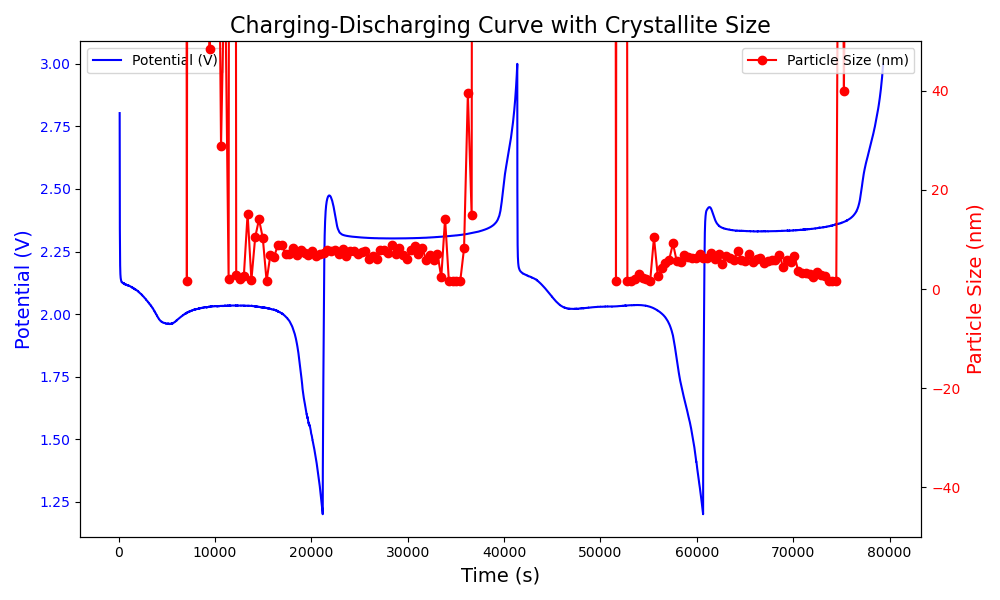

In [161]:
import matplotlib.pyplot as plt

# Use file_sorting to get the mapping between file numbers and times
starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=2, plot=False)

# Extract electrochemical data for plotting
capacity = elec_df_2['Discharge_Capacity'] if 'Discharge_Capacity' in elec_df_2.columns else None
time = elec_df_2['time/s']
voltage = elec_df_2['Ewe/V']

# Reverse the mapping to get File Key → Time
file_to_time_dict = {v: k for k, v in new_time_dict.items()}

# Check if df_results is valid and contains necessary columns
if not df_results.empty and 'File Key' in df_results.columns and 'Crystallite Size (nm)' in df_results.columns:
    # Map time from File Key
    df_results["Time (s)"] = df_results["File Key"].map(file_to_time_dict)

    # Filter out rows with missing time mapping
    valid_data = df_results.dropna(subset=["Time (s)"])

    particle_size_time = valid_data["Time (s)"].values
    particle_size = valid_data["Crystallite Size (nm)"].values
else:
    particle_size_time = []
    particle_size = []
    print("Warning: df_results is empty or missing required columns.")

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot voltage vs. time
ax1.plot(time, voltage, color='blue', label='Potential (V)')
ax1.set_xlabel('Time (s)', fontsize=14)
ax1.set_ylabel('Potential (V)', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')

# Plot crystallite size on a secondary y-axis
if len(particle_size_time) > 0 and len(particle_size) > 0:
    ax2 = ax1.twinx()
    ax2.plot(particle_size_time, particle_size, color='red', marker='o', label='Particle Size (nm)')
    ax2.set_ylabel('Particle Size (nm)', color='red', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(-50, 50)  # Adjust the limits as needed

    # Legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

# Title and layout
plt.title('Charging-Discharging Curve with Crystallite Size', fontsize=16)
plt.tight_layout()
plt.show()


# Fit with lorenzian 

# Multiple peak fit 

In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.integrate import simps
from ipywidgets import interact, IntSlider

starting_file, discharge_file, last_file, new_time_dict, elec_df_2 = file_sorting(starting_cycle=1, end_cycle=2, plot=False)
data_to_plot = corrected_individual_waxs_files

# Constants
wavelength = 0.154  # in nm
K = 0.9  # Scherrer shape factor
# min_x = 1.6
# max_x = 2.0
# min_x = 1.7
# max_x = 1.8
min_x = 1.8
max_x = 2.0
# min_x = 1.55
# max_x = 1.63
mean_positions = [1.85]

# Lorentzian peak model
def lorentzian(x, a, x0, gamma, baseline):
    return a * (0.5 * gamma)**2 / ((x - x0)**2 + (0.5 * gamma)**2) + baseline

def multi_lorentzian(x, *params):
    n_peaks = (len(params) - 1) // 3
    y = np.zeros_like(x)
    baseline = params[-1]
    for i in range(n_peaks):
        a = params[3*i]
        x0 = params[3*i + 1]
        gamma = params[3*i + 2]
        y += lorentzian(x, a, x0, gamma, 0)
    return y + baseline

# Dataframes to hold results
df_curves = pd.DataFrame()
df_scherrer = pd.DataFrame()

X_positions = data_to_plot[starting_file].iloc[:, 0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))
start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

amplitudes_for_avg = []

for file_number in range(starting_file, last_file + 1):
    x_filtered = data_to_plot[file_number].iloc[start_row:end_row+1, 0].values
    y_filtered = data_to_plot[file_number].iloc[start_row:end_row+1, 1].values
    y_filtered = savgol_filter(y_filtered, 7, 3)  # optional smoothing

    # Initial guess
    initial_guess = []
    for pos in mean_positions:
        initial_guess += [0.001, pos, 0.1]
    initial_guess += [np.min(y_filtered)]

    # Bounds
    lower_bounds = []
    upper_bounds = []
    for pos in mean_positions:
        lower_bounds += [0, pos - 0.01, 0.01]
        upper_bounds += [np.inf, pos + 0.01, 0.60]
    lower_bounds += [np.min(y_filtered)]
    upper_bounds += [0.1]

    bounds = (lower_bounds, upper_bounds)

    try:
        popt, pcov = curve_fit(
            multi_lorentzian, x_filtered, y_filtered,
            p0=initial_guess, bounds=bounds, max_nfev=100000
        )

        for i, pos in enumerate(mean_positions):
            amp = popt[3*i]
            center = popt[3*i + 1]
            gamma = popt[3*i + 2]
            baseline = popt[-1]
            perr = np.sqrt(np.diag(pcov))
            fwhm_err = perr[3*i + 2]

            df_curves.loc[file_number, f"Peak_{i+1}_Center"] = center
            df_curves.loc[file_number, f"Peak_{i+1}_FWHM"] = gamma
            df_curves.loc[file_number, f"Peak_{i+1}_Amplitude"] = amp
            df_curves.loc[file_number, f"Peak_{i+1}_Baseline"] = baseline
            df_curves.loc[file_number, f"Peak_{i+1}_FWHM error"] = fwhm_err

            amplitudes_for_avg.append(amp)

    except RuntimeError:
        print(f"Fit failed for file {file_number}")

# Reverse time mapping
file_to_time_dict = {v: k for k, v in new_time_dict.items()}

# Post-process for area, Scherrer size, and capacity
if amplitudes_for_avg:
    avg_amp = np.mean(amplitudes_for_avg)
    threshold = avg_amp / 5

    for file_number in range(starting_file, last_file + 1):
        for i in range(len(mean_positions)):
            try:
                amp = df_curves.loc[file_number, f"Peak_{i+1}_Amplitude"]
                fwhm = df_curves.loc[file_number, f"Peak_{i+1}_FWHM"]
                center = df_curves.loc[file_number, f"Peak_{i+1}_Center"]

                if amp >= threshold:
                    area = np.pi * amp * fwhm
                    df_curves.loc[file_number, f"Peak_{i+1}_Area"] = area

                    # Scherrer equation
                    theta_deg = 2 * np.degrees(np.arcsin((center * 10*wavelength) / (4 * np.pi)))
                    beta_deg = 2 * np.degrees(np.arcsin(((center + fwhm/2) * 10*wavelength) / (4 * np.pi))) - \
                                2 * np.degrees(np.arcsin(((center - fwhm/2) * 10*wavelength) / (4 * np.pi)))

                    beta_rad = np.radians(beta_deg)
                    theta_rad = np.radians(theta_deg / 2)
                    crystallite_size = (K * wavelength) / (beta_rad * np.cos(theta_rad))

                    df_scherrer.loc[file_number, f"Peak_{i+1}_Size"] = crystallite_size

                    # Error estimation
                    peak_fwhm_err = df_curves.loc[file_number, f"Peak_{i+1}_FWHM error"]
                    fwhm_plus = fwhm + peak_fwhm_err
                    fwhm_minus = fwhm - peak_fwhm_err
                    

                    beta_plus = 2 * np.degrees(np.arcsin(((center + fwhm_plus/2) * 10*wavelength) / (4 * np.pi))) - \
                                2 * np.degrees(np.arcsin(((center - fwhm_plus/2) * 10*wavelength) / (4 * np.pi)))

                    beta_minus = 2 * np.degrees(np.arcsin(((center + fwhm_minus/2) * 10*wavelength) / (4 * np.pi))) - \
                                    2 * np.degrees(np.arcsin(((center - fwhm_minus/2) * 10*wavelength) / (4 * np.pi)))

                    beta_plus_rad = np.radians(beta_plus)
                    beta_minus_rad = np.radians(beta_minus)

                    crystallite_plus = (K * wavelength) / (beta_plus_rad * np.cos(theta_rad))
                    crystallite_minus = (K * wavelength) / (beta_minus_rad * np.cos(theta_rad))

                    crystallite_error = abs(crystallite_plus - crystallite_minus) / 2

                    df_scherrer.loc[file_number, f"Peak_{i+1}_Size_Error"] = crystallite_error

            except KeyError:
                continue

        # Capacity calculation
        time_in_s = file_to_time_dict.get(file_number, None)
        if time_in_s is not None:
            capacity = (time_in_s * applied_current) / (active_material_mass * 3.6)
            df_curves.loc[file_number, "Capacity (mAh/g)"] = capacity

display(df_curves)

# Plotting interactive overlay
def plot_overlay(file_key):
    x = data_to_plot[file_key].iloc[start_row:end_row+1, 0].values
    y = data_to_plot[file_key].iloc[start_row:end_row+1, 1].values
    y = savgol_filter(y, 4, 3)

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, label='Smoothed Data', color='blue')

    y_fit_total = np.zeros_like(x)

    for i in range(len(mean_positions)):
        try:
            center = df_curves.loc[file_key, f"Peak_{i+1}_Center"]
            fwhm = df_curves.loc[file_key, f"Peak_{i+1}_FWHM"]
            amp = df_curves.loc[file_key, f"Peak_{i+1}_Amplitude"]
            baseline = df_curves.loc[file_key, f"Peak_{i+1}_Baseline"]

            y_fit = lorentzian(x, amp, center, fwhm, baseline)
            y_fit_total += y_fit
            plt.plot(x, y_fit, '--', label=f'Peak {i+1} Fit (q={center:.2f})')
        except KeyError:
            print(f"No fit parameters found for file {file_key}, peak {i+1}")
            continue

    plt.plot(x, y_fit_total, '-', label='Total Fit', color='red')
    plt.xlabel("q (nm⁻¹)")
    plt.ylabel("Intensity (a.u.)")
    plt.title(f"Overlayed Fit for File: {file_key}")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_overlay, file_key=IntSlider(min=starting_file, max=last_file, step=1, description='File Key'))



Biologic data file line details:
Line numbers for each electrochemical change event : [121, 4337, 8376, 12234, 15971]
Corresponding times for each electrochemical change event:  ['120.00', '21187.68', '41370.30', '60648.49', '79323.41']
Files numbers for SAXS data [1, 55, 106, 155, 202]


,Peak_1_Center,Peak_1_FWHM,Peak_1_Amplitude,Peak_1_Baseline,Peak_1_FWHM error,Capacity (mAh/g),Peak_1_Area
1,1.860000,0.599855,1.203239e-15,0.000320,0.000000e+00,0.000000,NaN
2,1.860000,0.599994,1.213803e-14,0.000378,0.000000e+00,18.331944,NaN
3,1.860000,0.599718,2.849845e-12,0.000296,1.189673e+07,36.663889,NaN
4,1.860000,0.599995,2.118429e-18,0.000334,0.000000e+00,54.949306,NaN
5,1.860000,0.599996,7.559423e-19,0.000317,0.000000e+00,73.281250,NaN
...,...,...,...,...,...,...,...
198,1.840001,0.356097,1.104519e-04,0.000243,1.056244e+00,3611.393056,0.000124
199,1.840209,0.482584,1.104113e-04,0.000187,3.265074e+00,3629.771528,0.000167
200,1.857793,0.546858,1.735153e-04,0.000080,4.448632e+00,3648.103472,0.000298
201,1.859998,0.599226,3.359239e-12,0.000264,8.056788e+06,3666.435417,NaN


interactive(children=(IntSlider(value=1, description='File Key', max=202, min=1), Output()), _dom_classes=('wi…

<function __main__.plot_overlay(file_key)>

# Plot the data 

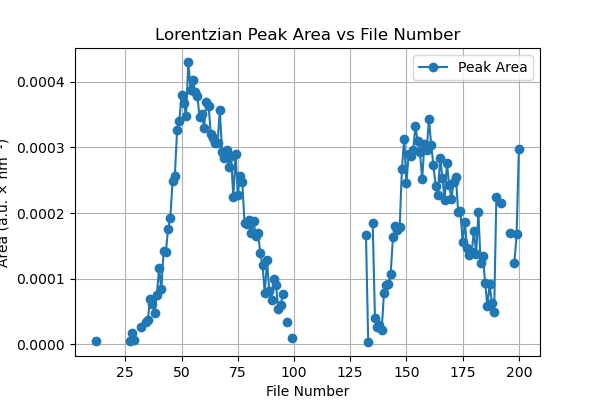

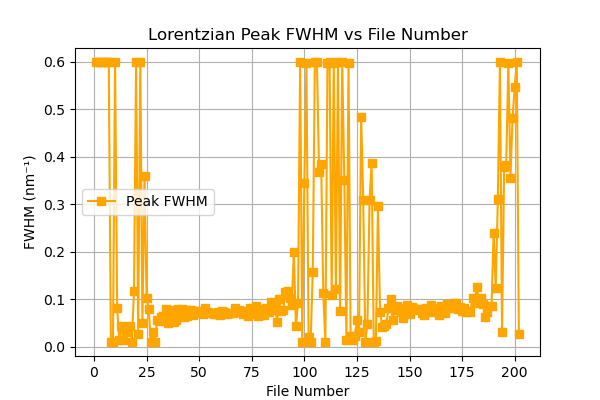

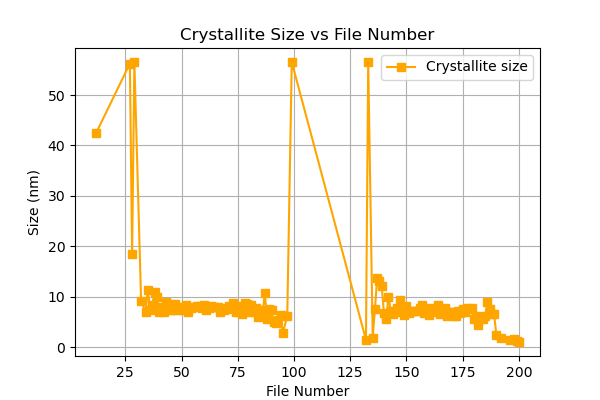

In [218]:
import matplotlib.pyplot as plt

# Get file numbers from the index (if not already the index, use .index)
file_numbers = df_curves.index

# Plot Area
plt.figure(figsize=(6, 4))
plt.plot(file_numbers, df_curves["Peak_1_Area"], marker='o', label='Peak Area')
plt.xlabel("File Number")
plt.ylabel("Area (a.u. × nm⁻¹)")
plt.title("Lorentzian Peak Area vs File Number")
plt.grid(True)
plt.legend()
plt.show()

# Plot FWHM
plt.figure(figsize=(6, 4))
plt.plot(file_numbers, df_curves["Peak_1_FWHM"], marker='s', color='orange', label='Peak FWHM')
plt.xlabel("File Number")
plt.ylabel("FWHM (nm⁻¹)")
plt.title("Lorentzian Peak FWHM vs File Number")
plt.grid(True)
plt.legend()
plt.show()

# Plot crystallite size
plt.figure(figsize=(6, 4))
plt.plot(df_scherrer.index, df_scherrer["Peak_1_Size"], marker='s', color='orange', label='Crystallite size')
plt.xlabel("File Number")
plt.ylabel("Size (nm)")
plt.title("Crystallite Size vs File Number")
plt.grid(True)
plt.legend()
plt.show()
